In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D

In [2]:
class GeneticAlgorithm:
  def __init__(self, point_size, map_size, fitness_function, population_size, selection_ratio, mutation_possibility, mutation_ratio, max_iter, termination_value) -> None:
    if point_size < 1:
      raise ValueError("point_size must be at least 1")
    if map_size < 1:
      raise ValueError("map_size must be at least 1")
    if mutation_possibility < 0 or mutation_possibility > 1:
      raise ValueError("mutation_possibility must be between 0 and 1")
    if mutation_ratio < 0 or mutation_ratio > 1:
      raise ValueError("mutation_ratio must be between 0 and 1")
    if selection_ratio < 0 or selection_ratio > 1:
      raise ValueError("selection_ratio must be between 0 and 1")
    if population_size % 2 != 0:
      raise ValueError("population_size must be even")
    if population_size < 4:
      raise ValueError("population_size must be at least 4")
    if max_iter < 1:
      raise ValueError("max_iter must be at least 1")

    self.point_size = point_size
    self.map_size = map_size
    self.fitness_function = fitness_function
    self.population_size = population_size
    self.selection_amount = int(selection_ratio * population_size)
    self.mutation_possibility = mutation_possibility
    self.mutation_ratio = mutation_ratio
    self.max_iter = max_iter
    self.termination_value = termination_value

  def optimize(self):
    points = [np.random.random(size=self.point_size) * self.map_size for _ in range(self.population_size)]
    iter_count = 0

    best_point, best_score = None, np.inf

    history = {}
    while best_score >= self.termination_value and iter_count < self.max_iter:
      points = sorted(points, key=lambda x: self.fitness_function(x))
      best_point = points[0]
      best_score = self.fitness_function(best_point)
      best_points = points[:self.selection_amount]
      history[iter_count] = {
          "best_point": best_point,
          "best_score": best_score,
          "points": points
      }
      print(f"iter {iter_count}: {best_score}")

      new_kids = []
      num_kids_to_create = self.population_size - self.selection_amount
      for i in range(num_kids_to_create):
          indices = np.random.choice(len(best_points), size=2, replace=False)
          p_a, p_b = best_points[indices[0]], best_points[indices[1]]

          new_kid = (p_a + p_b) / 2
          mutation = np.random.random() < self.mutation_possibility
          if mutation:
              new_kid += np.random.uniform(-1, 1, size=self.point_size) * self.mutation_ratio * self.map_size
          new_kids.append(new_kid)

      points = new_kids + best_points
      iter_count += 1

    return best_point, best_score, history

In [3]:
target_point = (np.random.random(size=3) * 400).round(5)
print(f"Target Point: {target_point}")

Target Point: [170.45431 288.02092  29.60402]


In [4]:
model = GeneticAlgorithm(
    point_size = 3,
    map_size = 400,
    fitness_function = lambda x: np.linalg.norm(x - target_point),
    population_size = 150,
    selection_ratio = 0.7,
    mutation_possibility = 0.5,
    mutation_ratio = 0.3,
    max_iter = 1000,
    termination_value = 1
)

In [5]:
best_point, best_score, history = model.optimize()
print(f"Best point: {best_point}")
print(f"Best score: {best_score}")

iter 0: 69.08114103258531
iter 1: 69.08114103258531
iter 2: 69.08114103258531
iter 3: 52.04955584069334
iter 4: 26.9124447579876
iter 5: 15.80379523158975
iter 6: 15.80379523158975
iter 7: 15.80379523158975
iter 8: 15.80379523158975
iter 9: 13.485297224728019
iter 10: 7.96848652328355
iter 11: 7.293005076502292
iter 12: 7.293005076502292
iter 13: 2.848041801761751
iter 14: 2.848041801761751
iter 15: 2.848041801761751
iter 16: 2.848041801761751
iter 17: 2.848041801761751
iter 18: 2.848041801761751
iter 19: 2.682965996892249
iter 20: 2.682965996892249
iter 21: 1.3913000490760141
iter 22: 1.3913000490760141
iter 23: 1.3913000490760141
iter 24: 1.3749737630503855
iter 25: 1.3749737630503855
iter 26: 1.2024252267716988
iter 27: 1.2024252267716988
iter 28: 0.8531117493579612
Best point: [170.93282345 287.66043158  30.21136886]
Best score: 0.8531117493579612


In [6]:
iters, best_scores = [], []
for key, value in history.items():
  iters.append(key)
  best_scores.append(value["best_score"])

Text(0.5, 1.0, 'Best Score vs Iteration')

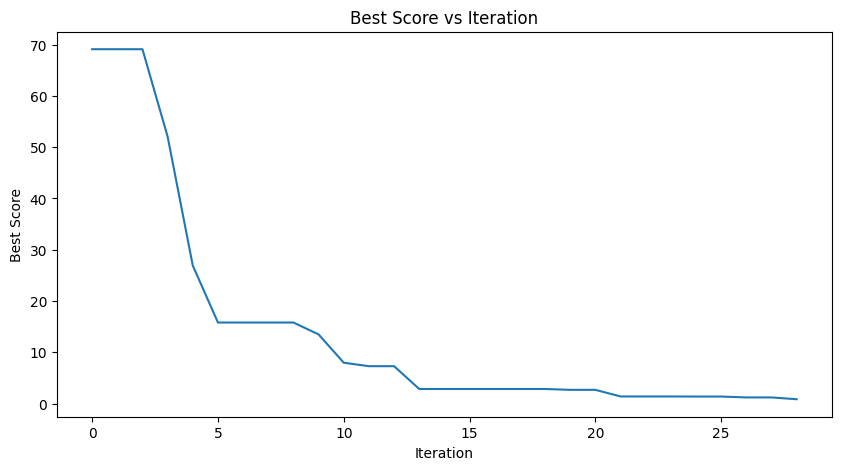

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(iters,best_scores)
plt.xlabel("Iteration")
plt.ylabel("Best Score")
plt.title("Best Score vs Iteration")

In [8]:
def plot_ga_3d_gif(history, map_size, filename="ga_evolution.gif", interval=200, elev=25, azim_start=-45, azim_step=0.8):
    all_iters = sorted(history.keys())
    total_steps = len(all_iters)

    if total_steps == 0:
        raise ValueError("No iteration that can be shown in history.")

    step_size = max(1, total_steps // 80)
    base_indices = list(range(0, total_steps, step_size))

    last_idx = total_steps - 1
    extended_indices = base_indices + [last_idx] * 20

    sample_point = history[all_iters[0]]["points"][0]
    dim = len(sample_point)
    if dim < 3:
        raise ValueError("Point size must be at least 3.")
    if dim > 3:
        print(f"Warning: point_size={dim}, sonly first 3 will be visualzed")

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")
    ax.grid(True, linestyle='--', alpha=0.5)

    ax.set_xlim(0, map_size)
    ax.set_ylim(0, map_size)
    ax.set_zlim(0, map_size)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    pop_scatter = ax.scatter([], [], [], c="royalblue", alpha=0.6, s=30, label="Population")
    best_scatter = ax.scatter([], [], [], c="red", s=150, marker="*", label="Best Point")

    ax.legend(loc="upper right")

    def init():
        pop_scatter._offsets3d = ([], [], [])
        best_scatter._offsets3d = ([], [], [])
        return pop_scatter, best_scatter

    def update(frame_idx):
        hist_idx = extended_indices[frame_idx]
        it = all_iters[hist_idx]

        data = history[it]
        points = np.array(data["points"])
        best_point = np.array(data["best_point"])
        best_score = data["best_score"]

        pop_scatter._offsets3d = (points[:, 0], points[:, 1], points[:, 2])
        best_scatter._offsets3d = ([best_point[0]], [best_point[1]], [best_point[2]])

        ax.set_title(f"Iteration {it} | Best Score: {best_score:.4f}", fontsize=11, weight='bold')

        cam_azimuth = azim_start + (frame_idx * azim_step)
        ax.view_init(elev=elev, azim=cam_azimuth)

        return pop_scatter, best_scatter

    anim = FuncAnimation(
        fig,
        update,
        frames=len(extended_indices),
        init_func=init,
        interval=interval,
        blit=False
    )

    print(f"GIF Saving: {filename} ...")
    anim.save(filename, writer=PillowWriter(fps=1000 // interval))
    plt.close(fig)
    print(f"GIF saved Successfully: {filename}")

    return anim

In [9]:
plot_ga_3d_gif(history, map_size=400, filename="ga_evolution.gif")

GIF Saving: ga_evolution.gif ...
GIF saved Successfully: ga_evolution.gif
